In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from keras.models import Sequential
from keras.layers import LSTM, Dense

In [15]:
# ======================
# Load Dataset
# ======================

df = pd.read_csv("stock_data_5yrs.csv")

df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].dt.tz_localize(None)

In [16]:
# ======================
# Encode Company Names
# ======================

le = LabelEncoder()
df['Company'] = le.fit_transform(df['Company'])
company_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

In [17]:
# ======================
# Date Feature
# ======================

df['Days'] = (df['Date'] - df['Date'].min()).dt.days

In [18]:
# ======================
# Clean Dataset
# ======================

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [19]:
# ======================
# Features & Target
# ======================

feature_cols = [col for col in df.columns if col not in ['Close','Date']]

scalerX = MinMaxScaler()
scalerY = MinMaxScaler()

In [20]:
# ======================
# TIME-BASED SPLIT PER COMPANY
# ======================

train_list = []
test_list = []

for company in df['Company'].unique():
    
    company_df = df[df['Company'] == company].sort_values('Date')
    
    min_date = company_df['Date'].min()
    split_date = min_date + pd.DateOffset(years=2)
    
    train_part = company_df[company_df['Date'] < split_date]
    test_part  = company_df[company_df['Date'] >= split_date]
    
    train_list.append(train_part)
    test_list.append(test_part)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

In [21]:
# ======================
# Prepare Train/Test Sets
# ======================

X_train = train_df[feature_cols].values
y_train = train_df['Close'].values.reshape(-1,1)

X_test = test_df[feature_cols].values
y_test = test_df['Close'].values.reshape(-1,1)

In [22]:
# ======================
# Scaling (FIT ONLY ON TRAIN)
# ======================

X_train = scalerX.fit_transform(X_train)
X_test = scalerX.transform(X_test)

y_train = scalerY.fit_transform(y_train)
y_test = scalerY.transform(y_test)

In [23]:
# ======================
# Reshape for LSTM
# ======================

X_train = X_train.reshape((X_train.shape[0],1,X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0],1,X_test.shape[1]))

In [24]:
# ======================
# LSTM Model
# ======================

model = Sequential()
model.add(LSTM(64, input_shape=(1,X_train.shape[2])))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100


c:\Users\FLEMIN P DANIEL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


763/763 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 2.4886e-04
Epoch 2/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.5732e-06
Epoch 3/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.7099e-06
Epoch 4/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.5649e-06
Epoch 5/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.9253e-06
Epoch 6/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.6655e-06
Epoch 7/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.7829e-06
Epoch 8/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.3265e-06
Epoch 9/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.2782e-06
Epoch 10/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.1079e-06
Epoch 11/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.5037e-06
Epoch 12/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.0333e-06
Epoch 13/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.5881e-06
Epoch 14/100
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.0704e-06

In [25]:
# ======================
# Regression Evaluation
# ======================

y_pred = model.predict(X_test)

y_test_inv = scalerY.inverse_transform(y_test)
y_pred_inv = scalerY.inverse_transform(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print("\nRegression Metrics:")
print("RMSE:", rmse)
print("MAE:", mae)

1052/1052 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Regression Metrics:
RMSE: 89.32873828935261
MAE: 36.1639393839378


In [26]:
# ======================
# Direction Classification
# ======================

y_test_direction = (np.diff(y_test_inv.flatten()) > 0).astype(int)
y_pred_direction = (np.diff(y_pred_inv.flatten()) > 0).astype(int)

accuracy = accuracy_score(y_test_direction, y_pred_direction)
precision = precision_score(y_test_direction, y_pred_direction)
recall = recall_score(y_test_direction, y_pred_direction)
f1 = f1_score(y_test_direction, y_pred_direction)

print("\nDirection Metrics:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Direction Metrics:
Accuracy: 0.8715427349157779
Precision: 0.8642628671125328
Recall: 0.8819061183312563
F1 Score: 0.872995359219879


In [27]:
# ======================
# USER INPUT (Company Only)
# ======================

company_name = input("\nEnter Company Name: ")

if company_name not in company_mapping:
    print("Company not found in dataset!")
else:
    encoded_company = company_mapping[company_name]

    # Get company data sorted
    company_df = df[df['Company'] == encoded_company].sort_values('Date')

    # Same split logic as training
    min_date = company_df['Date'].min()
    split_date = min_date + pd.DateOffset(years=2)

    company_test_df = company_df[company_df['Date'] >= split_date].copy()

    if len(company_test_df) == 0:
        print("Not enough test data for plotting.")
    else:

        # ======================
        # TEST PERIOD PLOT
        # ======================

        X_company_test = company_test_df[feature_cols].values
        y_company_test = company_test_df['Close'].values.reshape(-1,1)

        X_company_test = scalerX.transform(X_company_test)
        X_company_test = X_company_test.reshape((X_company_test.shape[0],1,X_company_test.shape[1]))

        y_company_pred_scaled = model.predict(X_company_test)
        y_company_pred = scalerY.inverse_transform(y_company_pred_scaled)

        dates = company_test_df['Date']

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


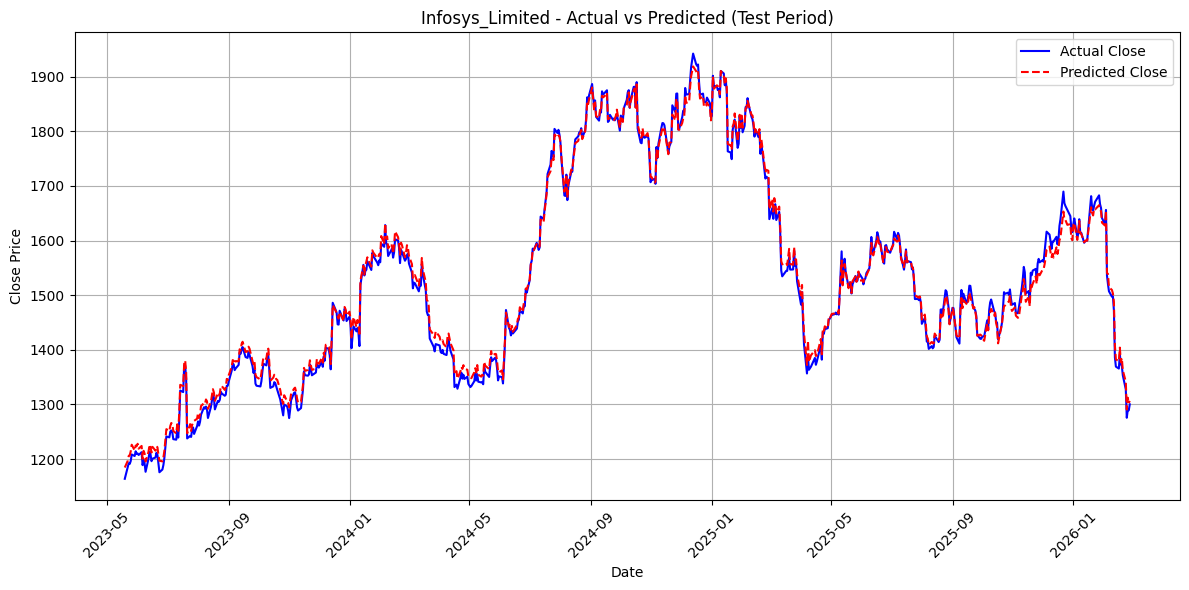

In [28]:
plt.figure(figsize=(12,6))
plt.plot(dates, y_company_test, color='blue', label="Actual Close")
plt.plot(dates, y_company_pred, color='red', linestyle='--', label="Predicted Close")

plt.title(f"{company_name} - Actual vs Predicted (Test Period)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
# ======================
# NEXT DAY PREDICTION
# ======================

last_row = company_df.iloc[-1:].copy()
last_date = last_row['Date'].values[0]

next_date = pd.to_datetime(last_date) + pd.Timedelta(days=1)
last_row['Days'] = (next_date - df['Date'].min()).days

X_next = last_row[feature_cols].values
X_next = scalerX.transform(X_next)
X_next = X_next.reshape((1,1,X_next.shape[1]))

next_pred_scaled = model.predict(X_next)
next_pred_price = scalerY.inverse_transform(next_pred_scaled)

print(f"\nNext Day Predicted Close Price for {company_name}: ₹{next_pred_price[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Next Day Predicted Close Price for Infosys_Limited: ₹1308.35
